# Tutorial 03 – Simulating solute diffusion in a root cross-section

In this tutorial we learn how MECHA simulates the **diffusion** of a solute through a root cross-section.

We proceed in three parts:

1. **The physics** – Fick's laws and the Gaussian wave-packet solution.
2. **The MECHA implementation** – how the continuous diffusion equation becomes a *network* problem, and how to drive it with `standard_solute_flux`.
3. **A hands-on simulation** – releasing a pulse in the cortex and watching it spread along two different pathways (apoplastic vs symplastic).

---

## Part 1 — The physics of diffusion

### 1.1 Fick's first law

Diffusion is the net movement of a solute from high to low concentration, driven by random motion. **Fick's first law** says the diffusive flux density $J$ (amount per unit area per unit time) is proportional to the negative concentration gradient:

$$ J = -D\,\nabla c $$

where

| symbol | meaning | units |
|--------|---------|-------|
| $c$ | concentration | $\text{mol cm}^{-3}$ |
| $D$ | diffusion coefficient | $\text{cm}^2\,\text{d}^{-1}$ |
| $J$ | flux density | $\text{mol cm}^{-2}\,\text{d}^{-1}$ |

The minus sign encodes *downhill* transport: solute flows toward lower $c$. This equation is called a **constitutive law** because it describes an empirical relationship rather than a fundamental principle.

### 1.2 Fick's second law (the diffusion equation)

Combining Fick's first law with conservation of mass $\partial_t c = -\nabla\!\cdot J$ (which is a fundamental principle) gives **Fick's second law**:

$$ \frac{\partial c}{\partial t} = D\,\nabla^2 c \qquad\Longrightarrow\qquad \frac{\partial c}{\partial t} = D\,\frac{\partial^2 c}{\partial x^2}\;\;\text{(1-D)} $$

### 1.3 The Gaussian wave packet (point-source solution)

If at $t=0$ all the solute (total amount $M$) sits at a single point $x=0$, the solution of the 1-D diffusion equation on an infinite line is a **Gaussian that spreads while keeping its area constant**:

$$ c(x,t) = \frac{M}{\sqrt{4\pi D t}}\,\exp\!\left(-\frac{x^2}{4 D t}\right) $$

This is a normal distribution with mean $\mu = 0$ and variance

$$ \sigma^2 = 2 D t \qquad\Longrightarrow\qquad \boxed{\;\sigma(t) = \sqrt{2 D t}\;\sim\;\sqrt{t}\;} $$

The experimental signatures of **Fickian diffusion** are therefore:

- the profile stays **bell-shaped (Gaussian)** at all times;
- the width $\sigma$ grows in proportion to $\sqrt{t}$;
- equivalently, $\sigma^2$ grows **linearly** in $t$, with slope $2D$.

We exploit this last relation below: fit a Gaussian at each time, plot $\sigma^2$ vs $t$, and read off the **effective diffusivity** $D_\text{eff} = \text{slope}/2$.

Let us first plot the analytical solution to build intuition.

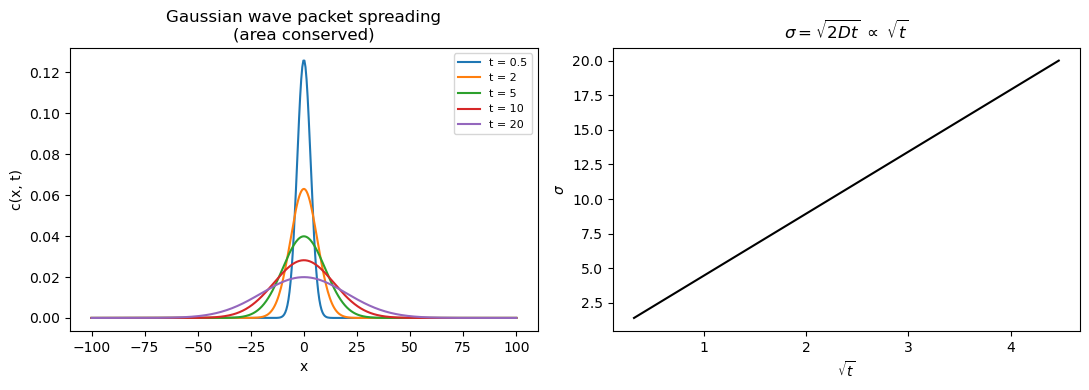

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Analytical 1-D point-source (Gaussian) solution of the diffusion equation.
def gaussian_pulse(x, t, D, M=1.0):
    return M / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))

x = np.linspace(-100, 100, 400)
D = 10.0  # arbitrary units (e.g. µm²/d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: profiles spread and flatten while conserving area.
for t in [0.5, 2, 5, 10, 20]:
    ax1.plot(x, gaussian_pulse(x, t, D), label=f"t = {t}")
ax1.set_xlabel("x"); ax1.set_ylabel("c(x, t)")
ax1.set_title("Gaussian wave packet spreading\n(area conserved)")
ax1.legend(fontsize=8)

# Right: sigma grows as sqrt(t)  ->  straight line through the origin.
t_arr = np.linspace(0.1, 20, 100)
ax2.plot(np.sqrt(t_arr), np.sqrt(2 * D * t_arr), 'k-')
ax2.set_xlabel(r"$\sqrt{t}$"); ax2.set_ylabel(r"$\sigma$")
ax2.set_title(r"$\sigma = \sqrt{2Dt}\;\propto\;\sqrt{t}$")

plt.tight_layout()
plt.show()

---
## Part 2 — How MECHA simulates diffusion

MECHA does **not** solve the continuous PDE on a mesh. Instead it solves a **network (graph) analogue** of it. A root cross-section is a graph whose nodes are *wall junctions* and *cell centres*, connected by edges representing the physical pathways between them. On this network the diffusion equation becomes a coupled system of ODEs:

$$ C_i\,\frac{dc_i}{dt} = \sum_j K_{ij}\,(c_j - c_i) $$

| symbol | meaning | units |
|--------|---------|-------|
| $c_i$ | concentration at node $i$ | — |
| $C_i$ | capacitance (storage volume) of node $i$ | $\text{cm}^3$ |
| $K_{ij}$ | conductance of the edge $i\!-\!j$ | $\text{cm}^3\,\text{d}^{-1}$ |

This is the **network form of Fick's law**: the flux along an edge is its conductance times the concentration difference across it. MECHA assembles this as a sparse **diffusion matrix** $D$ (positive off-diagonals $K_{ij}$, negative diagonal $-\sum_j K_{ij}$) and a diagonal **capacitance matrix** $C$.

### 2.1 Three transport pathways

A solute can cross a root by three physically distinct routes. The `diffusion_params` dictionary switches each on/off independently:

| key | pathway | route |
|-----|---------|-------|
| `apo_wall` | apoplastic | through the cell-wall continuum |
| `membrane` | transmembrane | passive crossing of the plasma membrane |
| `plasmodesmata` | symplastic | cell → cell through plasmodesmata |

The `mode` argument selects which sub-network is solved:

- `mode='full'` — all nodes (walls + cells); used for the **apoplastic + membrane** route (wall → membrane → cell).
- `mode='sym'` — cells only; used for the pure **symplastic** route (cell → PD → cell).

### 2.2 Time stepping — the θ (Crank–Nicolson) method

The ODE system is integrated in time with a θ-weighted scheme:

$$ \Big[\tfrac{C}{\Delta t} - \theta D\Big]\,c_\text{new} = \Big[\tfrac{C}{\Delta t} + (1-\theta) D\Big]\,c_\text{old} $$

| $\theta$ | scheme | properties |
|----------|--------|------------|
| 0 | explicit Euler | 1st order, can be unstable |
| **0.5** | **Crank–Nicolson** | **2nd order, used here** |
| 1 | implicit Euler | 1st order, very stable |

Crank–Nicolson ($\theta = 0.5$) is the sweet spot: second-order accurate in time and unconditionally stable for pure diffusion.

### 2.3 The single entry point: `standard_solute_flux`

All of this is driven by one method on the `Mecha` object:

```python
c_new = mecha.standard_solute_flux(
    diffusion_params   = {...},   # apo_wall / membrane / plasmodesmata (cm²/d)
    capacitance_params = {...},   # dt (days), C_wall, C_cell
    mode               = 'full',  # 'full' | 'sym' | 'apo'
    c_prev             = c_old,   # previous concentration vector
    theta              = 0.5,     # Crank–Nicolson
    operators          = 'D',     # 'D' diffusion only, 'A' advection, 'T' both
)
```

We pass `operators='D'` for **pure diffusion** (no water-driven advection) and call it once per time step in a loop.

---
## Part 3 — A hands-on simulation

### 3.1 Setup and build the network

We re-use the example anatomy bundled in `extdata/current_root.xml`. `water_flux()` must be called before any solute transport because the diffusion matrix re-uses the network geometry and conductances assembled by the hydraulic solver.

In [23]:
import os
import sys
import warnings

from scipy.optimize import curve_fit, OptimizeWarning
from scipy.stats import linregress

# Make the in-repo `openalea.mecha` package importable without installing it.
TUTORIAL_DIR = os.path.dirname(os.path.abspath("tutorial_03_diffusion.ipynb"))
sys.path.insert(0, os.path.join(TUTORIAL_DIR, "..", "src"))

from openalea.mecha import Mecha, InData, SoluteTransport, ScenarioBuilder

CELLSET = os.path.join(TUTORIAL_DIR, "..", "extdata", "current_root.xml")
OUT_DIR = os.path.join(TUTORIAL_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# Build and solve the hydraulic network.
data  = InData(cellset_file=CELLSET)
mecha = Mecha(data)
mecha.water_flux()
print("Network ready:",
      mecha.network.n_wall_junction, "wall nodes,",
      mecha.network.n_cells, "cells")

Setting default boundary conditions...
[DEBUG] tag_phi_thick_cells: 0, 1
unique ranks of tagged cells: []
unique ranks of tagged cells: []
Solving system
0.013727443001698703 seconds process time to solve system
--- 1 solutions computed ---
Total flow for scenario 0 and maturity stage 0: 0.002437840372260944
Network ready: 5270 wall nodes, 1055 cells


### 3.2 Define the two pathways to compare

We compare the **apoplastic** and **symplastic** routes side by side — exactly as `test/test_diffusion.py` does. The diffusivity values are chosen so the pulse stays well inside the cortex over the simulated window, giving a clean Fickian regime free of boundary effects.

In [24]:
# ── fictitious diffusion parameters (cm²/d) ──────────────────────────────────────────
D_WALL = 1e-4   # apoplastic (cell-wall) diffusivity
D_MEM  = 1e-6   # membrane diffusivity 
D_PD   = 5e-5   # plasmodesmatal diffusivity 

CASES = {
    "apo": dict(
        label="Apoplastic (wall + membrane)",
        color="#2166ac",
        dp=dict(apo_wall=D_WALL, membrane=D_MEM, plasmodesmata=0.0),
        mode="full",
    ),
    "sym": dict(
        label="Symplastic (plasmodesmata)",
        color="#d6604d",
        dp=dict(apo_wall=0.0, membrane=0.0, plasmodesmata=D_PD),
        mode="sym",
    ),
}

# Capacitance / time-stepping parameters.
#   dt      time step in days
#   C_wall  apoplast storage fraction (1.0 = full pore volume available)
#   C_cell  symplast storage fraction
CAP_PARAMS = {"dt": 1.0, "C_wall": 1.0, "C_cell": 1.0}

N_STEPS = 20    # 20 days; beyond this the pulse reaches the cortex edge
THETA   = 0.5   # Crank–Nicolson

### 3.3 Create a ring-shaped initial pulse in the cortex

We track the **cortex** cells (tissue group `cgroup == 4`) and place a pulse of $c = 1$ in a ring in the *middle* of the cortex. `ScenarioBuilder.circular_ic` fills the 40th–60th radial percentile band by default, which gives the ring its initial width.

In [25]:
# Locate the root centre and collect the cortex cells (cgroup == 4).
cx, cy = ScenarioBuilder.root_center(mecha)
cortex = ScenarioBuilder.collect_display_nodes(
    mecha, cx, cy, key="sym", filter_fn=lambda n: n.cgroup == 4)
r_vals = np.array([n.r for n in cortex])
print(f"Cortex cells tracked: {len(cortex)}  "
      f"(r = {r_vals.min():.0f}–{r_vals.max():.0f} µm)")

# Build the ring pulse + capacitance weights for each pathway.
ics, mass_weights, ring_bounds = {}, {}, {}
for key, case in CASES.items():
    c0, r_lo, r_hi = ScenarioBuilder.circular_ic(mecha, cortex, key=case["mode"])
    ics[key]         = c0
    ring_bounds[key] = (r_lo, r_hi)
    # Capacitance diagonal = per-node storage volume; used to check mass conservation.
    st = SoluteTransport(mecha, case["dp"], CAP_PARAMS, case["mode"])
    mass_weights[key] = st.build_capacitance(0).diagonal() * CAP_PARAMS["dt"]

r_lo, r_hi = ring_bounds["apo"]
r0_init    = 0.5 * (r_lo + r_hi)                  # ring centre radius
sigma_init = 0.5 * (r_hi - r_lo) / np.sqrt(2.0)   # initial Gaussian-width guess
print(f"Initial ring: r0 = {r0_init:.0f} µm, "
      f"bounds = [{r_lo:.0f}, {r_hi:.0f}] µm")

Cortex cells tracked: 259  (r = 174–378 µm)
Initial ring: r0 = 312 µm, bounds = [290, 333] µm


### 3.4 Run the time loop

We now march `N_STEPS` Crank–Nicolson diffusion steps for **both** pathways, calling `standard_solute_flux(..., operators='D')` once per step. After each step we fit a Gaussian to the cortex radial profile to track $\sigma(t)$, and we snapshot the field at selected times.

In [26]:
# ── Gaussian-fitting helper (cf. Part 1.3) ────────────────────────────────
def gaussian(r, A, r0, sigma):
    return A * np.exp(-(r - r0) ** 2 / (2.0 * sigma ** 2))

def fit_gaussian(r, c, r0_guess, sigma_guess):
    """Return (A, r0, sigma) or None if the fit is unreliable."""
    if c.max() < 1e-8:
        return None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", OptimizeWarning)
            popt, pcov = curve_fit(
                gaussian, r, c,
                p0=[c.max(), r0_guess, sigma_guess],
                bounds=([0, r0_guess * 0.5, 1.0],
                        [c.max() * 2, r0_guess * 1.5, 2000.0]),
                maxfev=8000)
        if np.sqrt(np.diag(pcov))[2] / (popt[2] + 1e-12) > 0.5:
            return None      # reject poorly constrained widths
        return tuple(popt)
    except (RuntimeError, ValueError):
        return None

# ── bookkeeping ───────────────────────────────────────────────────────────
# We keep only what the two output plots below actually consume:
#   snap_data -> spatial-evolution snapshots (§3.5)
#   ts_sigma / sig_data -> fitted Gaussian width sigma(t) for the analytical
#                          comparison sigma^2 = 2 D t (§3.6)
snap_at   = {0, 2, 5, 10, 15, 20}             # steps to snapshot
snap_data = {k: [] for k in CASES}
ts_sigma  = {k: [] for k in CASES}
sig_data  = {k: [] for k in CASES}
c_current = {k: ics[k].copy() for k in CASES}

def record(key, c_vec, step):
    t = float(step) * CAP_PARAMS["dt"]
    if CASES[key]["mode"] == "full":
        c_arr = np.array([float(c_vec[n.node_id]) for n in cortex])
    else:  # 'sym' -> indexed by cell_id
        c_arr = np.array([float(c_vec[n.cell_id]) for n in cortex])
    fit = fit_gaussian(r_vals, c_arr, r0_init, sigma_init)
    if fit is not None:
        ts_sigma[key].append(t)
        sig_data[key].append(abs(fit[2]))
    if step in snap_at:
        snap_data[key].append((c_vec.copy(), t))

for key in CASES:           # record the initial state (t = 0)
    record(key, c_current[key], 0)

# ── the time-stepping loop ────────────────────────────────────────────────
for step in range(1, N_STEPS + 1):
    for key, case in CASES.items():
        c_current[key] = mecha.standard_solute_flux(
            h=0, i_maturity=0, i_scenario=0,
            diffusion_params   = case["dp"],
            capacitance_params = CAP_PARAMS,
            mode               = case["mode"],
            c_prev             = c_current[key],
            theta              = THETA,
            operators          = "D",     # diffusion only
        )
        record(key, c_current[key], step)

print(f"Completed {N_STEPS} Crank–Nicolson steps for both pathways.")


Completed 20 Crank–Nicolson steps for both pathways.


### 3.5 Watch the pulse spread across the cross-section

Top row = apoplastic pathway, bottom row = symplastic. The cyan dashed circles mark the initial ring boundaries; you should see the bright band broaden and fade outward over time.

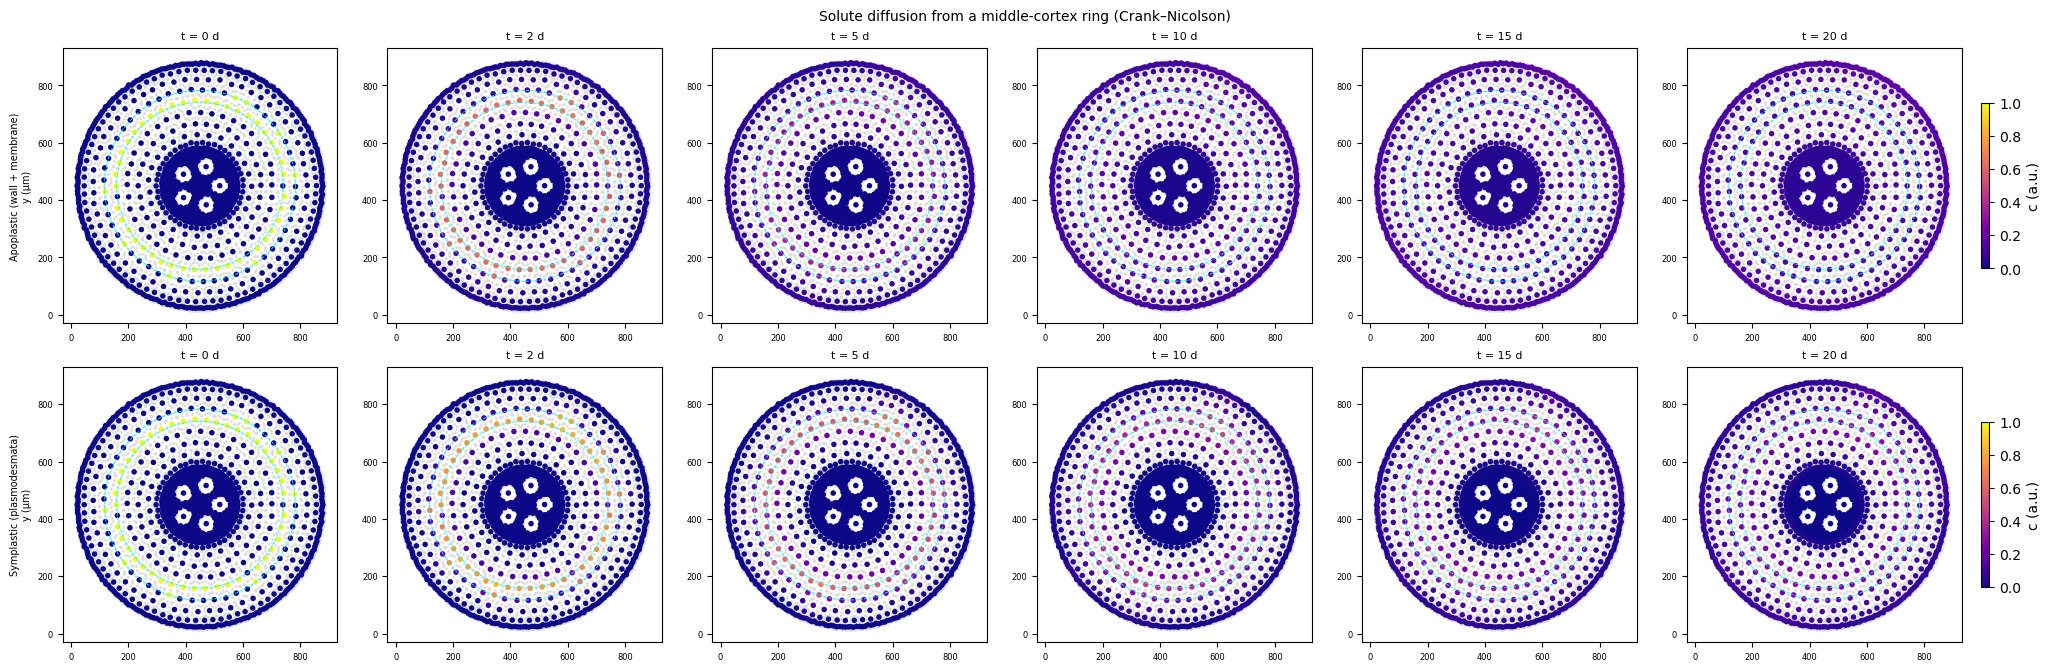

In [27]:
nwj   = mecha.network.n_wall_junction
graph = mecha.network.graph

cell_ent, wall_ent = [], []
for nd, d in graph.nodes(data=True):
    idx = mecha.indice[nd]
    pos = d.get("position", (0.0, 0.0))
    (cell_ent if idx >= nwj else wall_ent).append((idx, pos[0], pos[1]))

n_snap = len(snap_data["apo"])
fig, axes = plt.subplots(2, n_snap, figsize=(3.4 * n_snap, 6.6),
                         squeeze=False, layout="constrained")
vmax = max(c.max() for snaps in snap_data.values() for c, _ in snaps)
vmax = max(vmax, 1e-12)
theta_ring = np.linspace(0, 2 * np.pi, 300)

for row_i, (case_key, case) in enumerate(CASES.items()):
    sc_ref = None
    for col_j, (c_vec, t) in enumerate(snap_data[case_key]):
        ax = axes[row_i, col_j]
        if wall_ent:
            ax.scatter([e[1] for e in wall_ent], [e[2] for e in wall_ent],
                       s=1, c="#dddddd", zorder=1)
        if case["mode"] == "full":
            c_cell = [float(c_vec[e[0]]) for e in cell_ent]
        else:
            c_cell = [float(c_vec[e[0] - nwj]) for e in cell_ent]
        sc = ax.scatter([e[1] for e in cell_ent], [e[2] for e in cell_ent],
                        s=16, c=c_cell, cmap="plasma", vmin=0.0, vmax=vmax,
                        zorder=2, edgecolors="none")
        sc_ref = sc
        for rv in (r_lo, r_hi):
            ax.plot(cx + rv * np.cos(theta_ring), cy + rv * np.sin(theta_ring),
                    color="cyan", lw=0.6, ls="--", zorder=3)
        ax.set_aspect("equal", "box")
        ax.set_title(f"t = {t:.3g} d", fontsize=8)
        ax.tick_params(labelsize=6)
        if col_j == 0:
            ax.set_ylabel(f"{case['label']}\ny (µm)", fontsize=7)
    if sc_ref is not None:
        fig.colorbar(sc_ref, ax=axes[row_i, :].tolist(),
                     shrink=0.6, label="c (a.u.)", pad=0.01)

fig.suptitle("Solute diffusion from a middle-cortex ring (Crank–Nicolson)",
             fontsize=10)
plt.savefig(os.path.join(OUT_DIR, "diffusion_evolution.png"), dpi=150)
plt.show()

### 3.6 Does the simulation match the analytical prediction?

The spatial plots show the pulse broadening, but the quantitative test of **Fickian diffusion** (Part 1.3) is that the squared Gaussian width grows **linearly** in time:

$$ \sigma^2(t) = \sigma_0^2 + 2\,D_\text{eff}\,t $$

For each pathway we plot the fitted $\sigma^2(t)$ against $t$ and fit a straight line. If diffusion is Fickian the points fall on a line; its slope yields the **effective diffusivity** $D_\text{eff} = \text{slope}/2$, which we compare to the diffusivity we actually fed into MECHA.


Apoplastic (wall + membrane)      D_eff = 7.275e+02 µm²/d   (R² = 0.9237)
Symplastic (plasmodesmata)        D_eff = 1.071e+02 µm²/d   (R² = 0.9940)


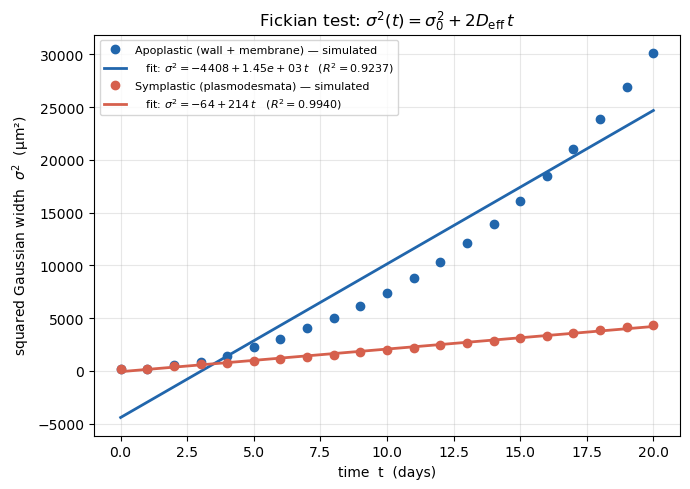

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))

for key, case in CASES.items():
    t   = np.asarray(ts_sigma[key])
    s2  = np.asarray(sig_data[key]) ** 2          # sigma^2 (µm²)
    if t.size < 2:
        continue

    # Linear fit  sigma^2 = sigma0^2 + 2 D_eff t  ->  slope = 2 D_eff.
    reg     = linregress(t, s2)
    D_eff   = reg.slope / 2.0                      # µm²/d
    D_input = max(case["dp"].values())             # the diffusivity we fed MECHA

    # Simulated points.
    ax.plot(t, s2, "o", color=case["color"], ms=6,
            label=f"{case['label']} — simulated")
    # Best-fit line (the analytical Fickian form).
    ax.plot(t, reg.intercept + reg.slope * t, "-", color=case["color"], lw=2,
            label=(rf"   fit: $\sigma^2 = {reg.intercept:.0f} + "
                   rf"{reg.slope:.3g}\,t$   ($R^2={reg.rvalue**2:.4f}$)"))

    print(f"{case['label']:<32s}  D_eff = {D_eff:.3e} µm²/d   "
          f"(R² = {reg.rvalue**2:.4f})")

ax.set_xlabel("time  t  (days)")
ax.set_ylabel(r"squared Gaussian width  $\sigma^2$  (µm²)")
ax.set_title(r"Fickian test: $\sigma^2(t) = \sigma_0^2 + 2 D_\mathrm{eff}\,t$")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "diffusion_sigma2_vs_t.png"), dpi=150)
plt.show()


### 3.7 Why does the test pass for the symplast but bend upward for the apoplast?

The symplastic points sit almost perfectly on the straight line ($R^2 = 0.994$), while the apoplastic points curve **upward** — they grow faster than linearly, with a visibly super-linear (roughly quadratic) shape and a much poorer fit ($R^2 = 0.924$). This is not a numerical artefact; it tells us something physical about the two pathways.

**Why the symplast obeys $\sigma^2 = \sigma_0^2 + 2 D_\mathrm{eff} t$ so well**

- The symplastic sub-network (`mode='sym'`) is **homogeneous**: every edge is a cell→cell plasmodesmatal connection with the *same* conductance, and every node is a cell with the *same* capacitance. A network of identical conductances and capacitances is exactly the discrete analogue of a constant-coefficient Fick's law, so the pulse spreads as a genuine Gaussian whose squared width grows linearly in time.
- The chosen diffusivity ($D_\text{PD}$) is small enough that over the 20-day window the pulse stays **well inside the cortex**. It never feels the cortex boundaries, so it diffuses as if in an unbounded, uniform medium — precisely the regime the analytical formula assumes.

**Why the apoplast bends upward (super-linear / quadratic growth)**

- The apoplastic case runs on the **`full`** network (walls **and** cells) and mixes **two very different conductances**: a fast cell-wall continuum ($D_\text{wall}=10^{-4}$) coupled through much slower membrane crossings ($D_\text{mem}=10^{-6}$). This is a **heterogeneous, two-scale medium**, not a single-coefficient Fickian one, so a single Gaussian width is only a crude summary of the real profile — the fitted $\sigma$ becomes unreliable (hence the lower $R^2$).
- The effective apoplastic diffusivity is much larger ($D_\text{eff}\approx 7.3\times10^{2}$ vs. $1.1\times10^{2}\ \mu m^2/\text d$). The pulse therefore **spreads far faster** and, well before $t=20$ d, its tail reaches the **inner/outer edges of the cortex**. Once the front hits a no-flux boundary, the concentration piles up there instead of continuing to spread outward; the Gaussian fit absorbs this as an *apparent* acceleration of $\sigma^2$, producing the upward (quadratic-looking) curvature.
- The cross-section geometry adds to this: spreading **outward** moves solute into rings of larger circumference (more wall paths), so the radial profile is not the symmetric Gaussian assumed by the 1-D analytical solution. This asymmetry grows with distance travelled, again steepening $\sigma^2(t)$.

**Take-away.** The Fickian test is only valid while the pulse (i) lives in a medium with a *single* effective diffusivity and (ii) stays far from the domain boundaries. The symplastic run satisfies both and lands on the line; the apoplastic run violates both — heterogeneous wall/membrane conductances plus a fast front that hits the cortex edge — so it departs from linearity and curves upward. To recover a clean apoplastic line one would lower $D_\text{wall}$ (or shorten the time window) so the pulse again stays well inside the cortex.
